basophil       1212
eosinophil     3110
erythroblast   1551
ig             2892
lymphocyte     1214
monocyte       1419
neutrophil     3328
platelet       2348
Total: 17074


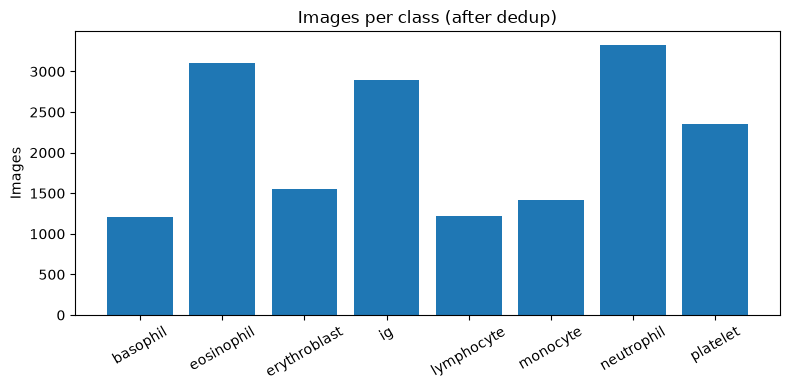

In [1]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

SEED = 11
random.seed(SEED)

data_dir = Path("../data/blood")
class_names = sorted(p.name for p in data_dir.iterdir() if p.is_dir())
counts = {c: len(list((data_dir / c).glob("*.jpg"))) for c in class_names}

for c, n in counts.items():
    print(f"{c:14s} {n}")
print("Total:", sum(counts.values()))

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts.values())
plt.title("Images per class (after dedup)")
plt.ylabel("Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../images/blood_class_counts.png", dpi=200, bbox_inches="tight")
plt.show()

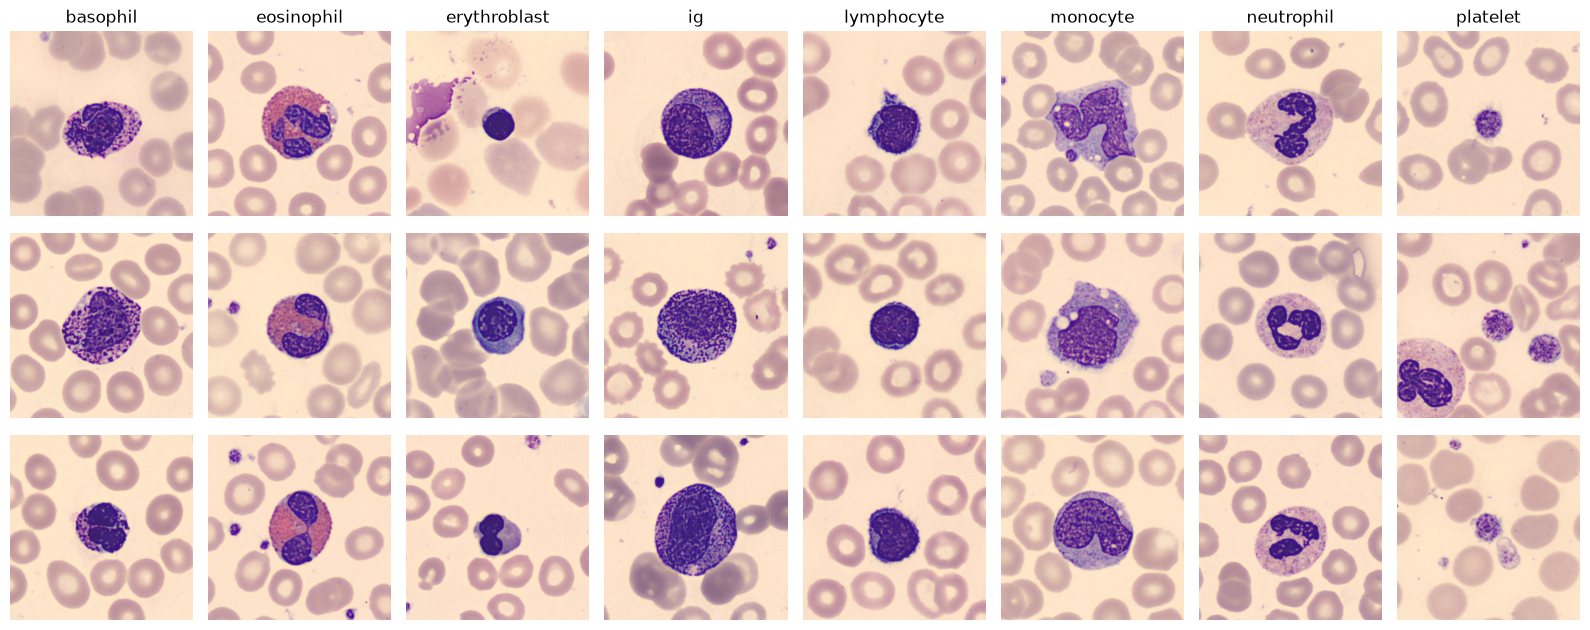

In [2]:
n_rows = 3
fig, axes = plt.subplots(n_rows, len(class_names), figsize=(16, 6.5))

for col, c in enumerate(class_names):
    files = random.sample(sorted((data_dir / c).glob("*.jpg")), n_rows)
    for row, f in enumerate(files):
        ax = axes[row, col]
        ax.imshow(Image.open(f))
        ax.axis("off")
        if row == 0:
            ax.set_title(c)

plt.tight_layout()
plt.savefig("../images/blood_samples.png", dpi=200, bbox_inches="tight")
plt.show()


# Splitting

In [3]:
import json
from collections import Counter
from sklearn.model_selection import train_test_split

# Paths relative to data_dir, so both the notebook and the script can use them
paths, labels = [], []
for label, c in enumerate(class_names):
    for f in sorted((data_dir / c).glob("*.jpg")):
        paths.append(f"{c}/{f.name}")
        labels.append(label)

# 70% train, then split the remaining 30% in half: 15% val, 15% test
train_p, temp_p, train_y, temp_y = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=SEED)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED)

print("train / val / test:", len(train_p), len(val_p), len(test_p))
for name, y in [("train", train_y), ("val", val_y), ("test", test_y)]:
    print(f"{name:5s}", [Counter(y)[i] for i in range(len(class_names))])

split = {"class_names": class_names,
         "train": list(zip(train_p, train_y)),
         "val":   list(zip(val_p, val_y)),
         "test":  list(zip(test_p, test_y))}
Path("../results").mkdir(exist_ok=True)
with open("../results/blood_split.json", "w") as f:
    json.dump(split, f)


train / val / test: 11951 2561 2562
train [848, 2177, 1086, 2024, 850, 993, 2329, 1644]
val   [182, 466, 233, 434, 182, 213, 499, 352]
test  [182, 467, 232, 434, 182, 213, 500, 352]


# Before / After Resize
Evidences for Task 2

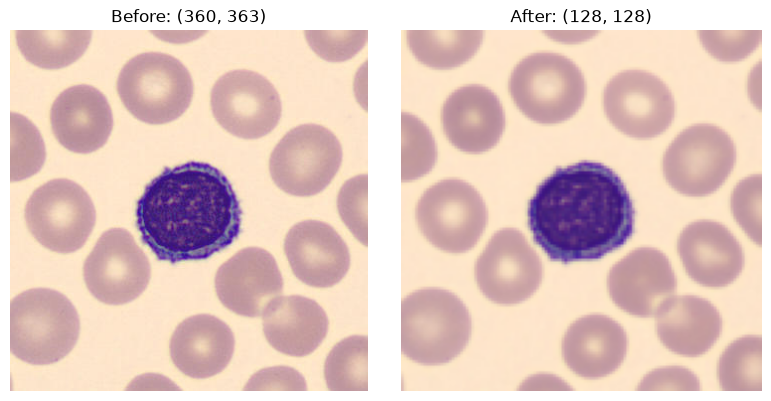

In [4]:
IMG_SIZE = 128
example = data_dir / train_p[0]
orig = Image.open(example)
resized = orig.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(orig);    ax[0].set_title(f"Before: {orig.size}")
ax[1].imshow(resized); ax[1].set_title(f"After: {resized.size}")
for a in ax: a.axis("off")
plt.tight_layout()
plt.savefig("../images/blood_before_after_resize.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
import sys
sys.path.insert(0, "../scripts")
from blood_data import load_split, make_dataset # modular functions from scripts/blood_data.py

split = load_split()
train_ds = make_dataset(split, "train", shuffle=True)
val_ds   = make_dataset(split, "val")
test_ds  = make_dataset(split, "test")

x_batch, y_batch = next(iter(train_ds))
print("batch:", x_batch.shape, x_batch.dtype)
print("pixel range:", float(x_batch.numpy().min()), "-", float(x_batch.numpy().max()))
print("labels:", y_batch.numpy()[:10])


batch: (32, 128, 128, 3) <dtype: 'float32'>
pixel range: 0.0117647061124444 - 1.0
labels: [1 1 0 6 6 2 1 1 2 1]


# Data Augmentation

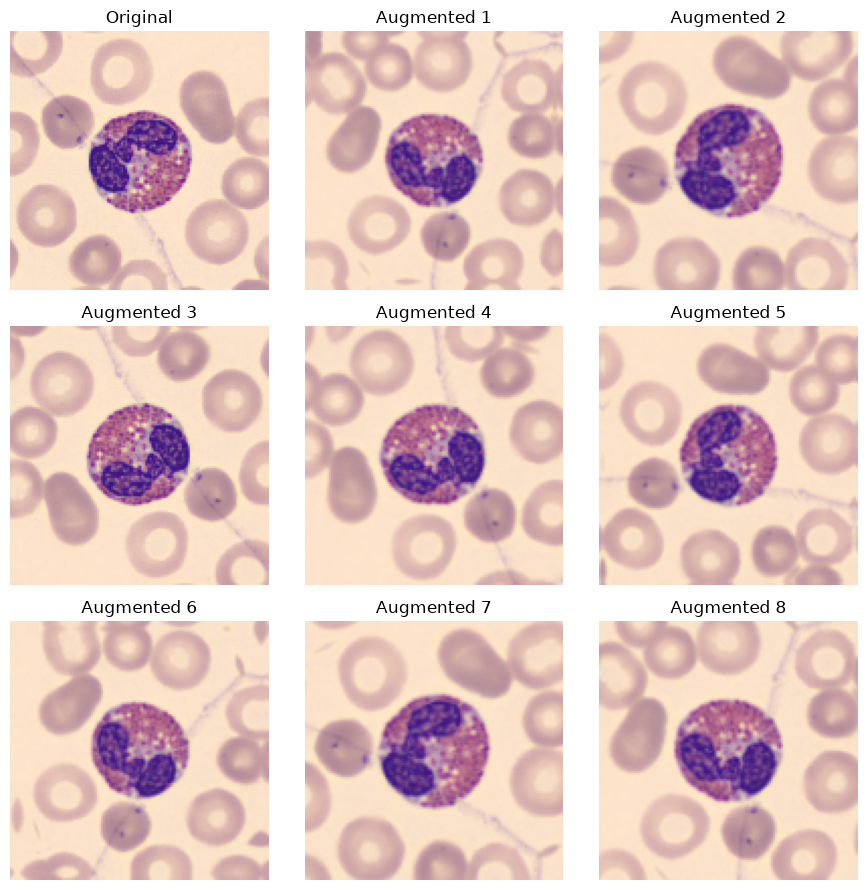

In [ ]:
from blood_model import make_augmentation

augment = make_augmentation()
img = x_batch[:1]  # one training image, shape (1, 128, 128, 3)

plt.figure(figsize=(9, 9))
plt.subplot(3, 3, 1)
plt.imshow(img[0].numpy()); plt.title("Original"); plt.axis("off")
for i in range(2, 10):
    aug = augment(img, training=True)
    plt.subplot(3, 3, i)
    plt.imshow(aug[0].numpy()); plt.title(f"Augmented {i-1}"); plt.axis("off")
plt.tight_layout()
plt.savefig("../images/blood_augmentation_examples.png", dpi=200, bbox_inches="tight")
plt.show()
